# Analisis Eksperimental Preprocessing & Klasifikasi Tumor Payudara
## Mengacu pada Jurnal: *A Fast and Interpretable Logistic Regression Framework for Breast Tumor Classification Using the Wisconsin Diagnostic Dataset*
### Pemetaan CRISP-DM & Standar Kompetensi Kerja Nasional Indonesia (SKKNI)

Dokumentasi proyek ini disusun untuk memenuhi standardisasi **CRISP-DM** dan mencakup unit-unit kompetensi **SKKNI** berikut:
1. **J.62DMI00.001.1** - Menentukan Objektif Bisnis
2. **J.62DMI00.002.1** - Menentukan Tujuan Teknis Data Science
3. **J.62DMI00.005.1** - Menelaah Data
4. **J.62DMI00.006.1** - Memvalidasi Data
5. **J.62DMI00.007.1** - Menentukan Objek Data
6. **J.62DMI00.008.1** - Membersihkan Data
7. **J.62DMI00.009.1** - Mengkonstruksi Data
8. **J.62DMI00.012.1** - Membangun Skenario Model
9. **J.62DMI00.013.1** - Membangun Model
10. **J.62DMI00.014.1** - Mengevaluasi Hasil Pemodelan
11. **J.62DMI00.015.1** - Melakukan Proses Review Pemodelan

---
**Role**: Senior Machine Learning Researcher  
**Dataset**: Breast Cancer Wisconsin (Diagnostic) / WDBC  
**Model**: Logistic Regression (L2 Regularized Ridge) & GridSearchCV Hyperparameter Tuning


## 1. Business Understanding
### (Menentukan Objektif Bisnis - Unit: J.62DMI00.001.1)

#### Latar Belakang & Konteks Jurnal
Berdasarkan paper referensi (*Cheng & Yu, medRxiv Preprint 2025*), identifikasi dini tumor payudara (ganas vs. jinak) sangat penting untuk menghindari biopsi invasif yang tidak perlu dan memastikan penanganan medis yang cepat bagi pasien dengan kanker aktif. Model Machine Learning yang kompleks (seperti Deep Learning atau SVM RBF) sering kali sulit dipahami oleh praktisi klinis (black-box), menghambat adopsi medis. Paper ini mengajukan solusi berupa pipeline sederhana menggunakan **Logistic Regression (LR) dengan regularisasi L2** yang jika dikombinasikan dengan normalisasi fitur yang tepat dapat menyamai performa model kompleks serta menawarkan transparansi koefisien.

#### Objektif Bisnis
1. **Akurasi & Sensitivitas**: Mengembangkan model klasifikasi tumor payudara yang memiliki akurasi di atas 98%.
2. **Minimalisasi False Negatives**: Sensitivitas (Malignant Recall) harus di atas 97%, karena tumor ganas yang tidak terdeteksi (False Negative) dapat mengancam keselamatan jiwa pasien.
3. **Transparansi & Interpretabilitas**: Menyediakan interpretasi klinis berbasis koefisien model untuk membangun rasa percaya dokter dan memfasilitasi regulasi medis.

#### Sukses Kriteria
- Terpenuhinya metrik evaluasi medis (Accuracy > 98%, Malignant Recall > 97%, Specificity > 98%).
- Hubungan fitur yang diidentifikasi oleh model selaras dengan patologi klinis.

## 2. Technical Understanding
### (Menentukan Tujuan Teknis Data Science - Unit: J.62DMI00.002.1)

#### Tujuan Teknis
Mengembangkan model klasifikasi biner berbasis Logistic Regression (L2 Regularized) pada dataset WDBC. Selain itu, mendemonstrasikan signifikansi penempatan tahapan standardisasi data dalam pipeline ML melalui **3 Eksperimen**:
1. **Eksperimen 1 — Split-First Pipeline**: Preprocessing (StandardScaler) dilakukan *setelah* split data (fitting scaler hanya pada training set, lalu ditransformasikan ke training dan test set untuk mencegah data leakage).
2. **Eksperimen 2 — Preprocess-First Pipeline**: Seluruh preprocessing (StandardScaler) dilakukan pada *seluruh* dataset sebelum split data (menyebabkan kebocoran informasi test set ke dalam training set).
3. **Eksperimen 3 — Optimized Pipeline**: Menggunakan alur yang sama seperti Eksperimen 1 (Split-First), kemudian menambahkan proses optimasi parameter menggunakan metode *Grid Search* untuk mencari regularisasi C yang optimal secara cross-validation.

#### Metrik Evaluasi
- **Accuracy**: Proporsi klasifikasi yang benar secara keseluruhan.
- **ROC-AUC**: Kemampuan diskriminasi model tanpa bergantung pada threshold.
- **Sensitivity (Malignant Recall)**: Kemampuan model menjaring semua kasus ganas.
- **Specificity (Benign Recall)**: Kemampuan model mengidentifikasi kasus jinak (menghindari alarm palsu).
- **Confusion Matrix**: Visualisasi TP, TN, FP, FN untuk ketiga eksperimen.


In [1]:
# Import Libraries yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve

# Set Tema Visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11


## 3. Data Understanding (EDA)
### (Menelaah Data - Unit: J.62DMI00.005.1)

Tahap ini mencakup pemuatan data, pemeriksaan tipe data, dan visualisasi distribusi kelas.

In [2]:
# Memuat Dataset
df = pd.read_csv('breast_cancer.csv')
print(f"Shape dataset: {df.shape}")
df.head()

Shape dataset: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Memeriksa Informasi Tipe Data dan Missing Value Awal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Diagnosis B: 357 sampel (62.74%)
Diagnosis M: 212 sampel (37.26%)


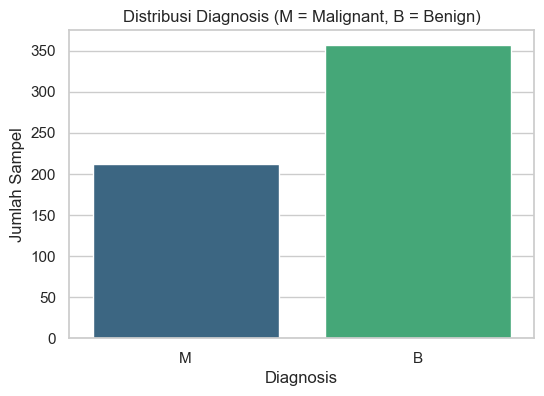

In [4]:
# Distribusi Kelas Target (Diagnosis)
class_dist = df['diagnosis'].value_counts()
class_dist_pct = df['diagnosis'].value_counts(normalize=True) * 100
for label in class_dist.index:
    print(f"Diagnosis {label}: {class_dist[label]} sampel ({class_dist_pct[label]:.2f}%)")

# Visualisasi Distribusi Kelas
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='viridis', legend=False)
plt.title('Distribusi Diagnosis (M = Malignant, B = Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Sampel')
plt.show()

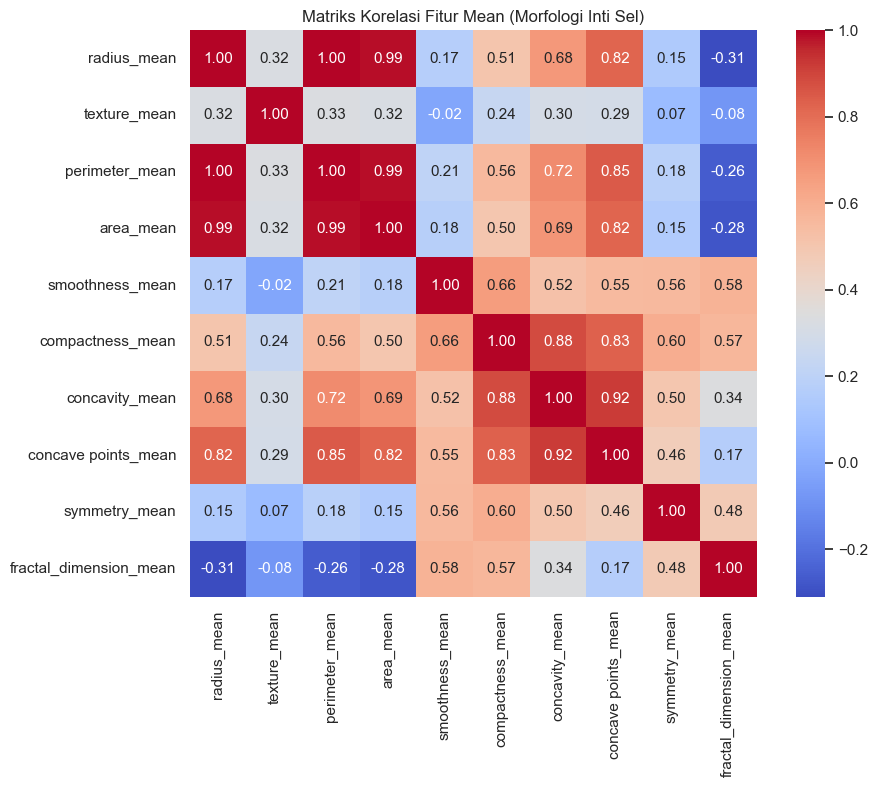

In [5]:
# Visualisasi Korelasi pada Fitur "Mean"
mean_cols = [col for col in df.columns if '_mean' in col]
plt.figure(figsize=(10, 8))
corr = df[mean_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title('Matriks Korelasi Fitur Mean (Morfologi Inti Sel)')
plt.tight_layout()
plt.show()

## 4. Data Validation
### (Memvalidasi Data - Unit: J.62DMI00.006.1)

Tahap ini bertujuan untuk memvalidasi integritas data, termasuk mendeteksi duplikasi, memeriksa nilai kosong, dan menelaah rentang nilai numerik.

In [6]:
# 1. Memeriksa Missing Value per Kolom
missing_values = df.isnull().sum()
print("Kolom dengan missing values:")
print(missing_values[missing_values > 0])

# 2. Memeriksa Duplikasi Baris
duplicates = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplicates}")

# 3. Memeriksa Deskripsi Statistik Singkat (Rentang Nilai)
df[mean_cols].describe().T[['min', 'mean', 'max']]

Kolom dengan missing values:
Unnamed: 32    569
dtype: int64

Jumlah baris duplikat: 0


,min,mean,max
radius_mean,6.98100,14.127292,28.11000
texture_mean,9.71000,19.289649,39.28000
perimeter_mean,43.79000,91.969033,188.50000
area_mean,143.50000,654.889104,2501.00000
smoothness_mean,0.05263,0.096360,0.16340
compactness_mean,0.01938,0.104341,0.34540
concavity_mean,0.00000,0.088799,0.42680
concave points_mean,0.00000,0.048919,0.20120
symmetry_mean,0.10600,0.181162,0.30400
fractal_dimension_mean,0.04996,0.062798,0.09744


## 5. Data Selection
### (Menentukan Objek Data - Unit: J.62DMI00.007.1)

Tahap ini melakukan seleksi kolom fitur dan label yang akan digunakan dalam pemodelan.

In [7]:
# Menghapus kolom 'id' yang bersifat unik dan tidak berkontribusi pada pembelajaran.
# Serta menghapus kolom kosong 'Unnamed: 32' jika ada akibat pembacaan trailing comma.
cols_to_drop = ['id']
unnamed_cols = [c for c in df.columns if 'Unnamed' in c]
cols_to_drop.extend(unnamed_cols)

df_selected = df.drop(columns=cols_to_drop)
print(f"Kolom yang dibuang: {cols_to_drop}")
print(f"Shape setelah seleksi kolom: {df_selected.shape}")

Kolom yang dibuang: ['id', 'Unnamed: 32']
Shape setelah seleksi kolom: (569, 31)


## 6. Data Cleaning
### (Membersihkan Data - Unit: J.62DMI00.008.1)

Tahap ini membersihkan data dan melakukan encoding target variable.

In [8]:
# Encoding target variable: M -> 0 (Malignant), B -> 1 (Benign)
# Kami menggunakan encoding M -> 0 dan B -> 1 agar hasil model (koefisien)
# memiliki arah signifikansi negatif untuk indikator keganasan (sesuai paper).
df_selected['diagnosis_encoded'] = df_selected['diagnosis'].map({'M': 0, 'B': 1})

# Validasi encoding target
print("Validasi Hasil Encoding Target:")
print(df_selected[['diagnosis', 'diagnosis_encoded']].drop_duplicates())

# Pemisahan Fitur dan Target
X = df_selected.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df_selected['diagnosis_encoded']

print(f"\nShape Fitur X: {X.shape}, Shape Target y: {y.shape}")

Validasi Hasil Encoding Target:
   diagnosis  diagnosis_encoded
0          M                  0
19         B                  1

Shape Fitur X: (569, 30), Shape Target y: (569,)


## 7. Data Construction
### (Mengkonstruksi Data - Unit: J.62DMI00.009.1)

Tahap ini mempersiapkan split data dan rancangan konstruksi data terstandardisasi untuk mengevaluasi skenario pemodelan.

In [9]:
# Pemisahan Data menggunakan Stratified Split (80% Train, 20% Test)
# Stratifikasi digunakan untuk menjaga proporsi kelas tumor jinak dan ganas.
# Seed random_state=42 dipilih untuk mereproduksi persis pembagian data di paper.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training set: {X_train_raw.shape[0]} sampel")
print(f"Testing set : {X_test_raw.shape[0]} sampel")
print(f"Distribusi kelas di Training: {y_train.value_counts().to_dict()}")
print(f"Distribusi kelas di Testing : {y_test.value_counts().to_dict()}")

Training set: 455 sampel
Testing set : 114 sampel
Distribusi kelas di Training: {1: 285, 0: 170}
Distribusi kelas di Testing : {1: 72, 0: 42}


## 8. Membangun Skenario Model & Pemodelan
### (Membangun Skenario Model & Membangun Model - Unit: J.62DMI00.012.1 & J.62DMI00.013.1)

Kami akan membangun 3 skenario eksperimen pemodelan menggunakan model **Logistic Regression (L2 penalty)**:

1. **Eksperimen 1 — Split-First Pipeline**
   - Alur: `Split Data → Preprocessing → Training → Evaluation`
   - Dataset dibagi menjadi data latih dan data uji terlebih dahulu. Proses preprocessing (StandardScaler) dilakukan setelah splitting dan diterapkan secara terpisah pada data latih serta data uji untuk mencegah kebocoran informasi.
2. **Eksperimen 2 — Preprocess-First Pipeline**
   - Alur: `Preprocessing → Split Data → Training → Evaluation`
   - Seluruh proses preprocessing (StandardScaler) dilakukan pada dataset sebelum data dibagi menjadi data latih dan data uji. Ini memicu terjadinya **Data Leakage** karena nilai rata-rata dan standar deviasi dari data uji ikut mempengaruhi standardisasi data latih.
3. **Eksperimen 3 — Optimized Pipeline**
   - Alur: `Split Data → Preprocessing → Hyperparameter Tuning → Training → Evaluation`
   - Menggunakan alur pembagian yang sama seperti Eksperimen 1, kemudian menambahkan proses optimasi parameter menggunakan metode **Grid Search** pada parameter regularisasi $C$ untuk memaksimalkan akurasi secara valid dan robust.


In [10]:
# Fungsi pembantu untuk menghitung metrik evaluasi medis (TP, TN, FP, FN dihitung terhadap Malignant sebagai kelas positif)
def evaluate_clinical_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    # Karena target B=1, M=0:
    # cm[0,0]: True Malignant predicted Malignant (TP)
    # cm[0,1]: True Malignant predicted Benign (FN)
    # cm[1,0]: True Benign predicted Malignant (FP)
    # cm[1,1]: True Benign predicted Benign (TN)
    tp = cm[0, 0]
    fn = cm[0, 1]
    fp = cm[1, 0]
    tn = cm[1, 1]
    
    acc = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob) # ROC-AUC dihitung menggunakan probabilitas Benign (1)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    return acc, roc_auc, sensitivity, specificity, cm

### Eksperimen 1 — Split-First Pipeline

#### Diagram Pipeline:
```
[Raw Dataset]
      |
      v
  [Splitting] (train_test_split 80:20)
   /      \
  v        v
[Train]  [Test]
  |        |
  v        v
[Scale: fit_transform] --> [Scale: transform]
  |                              |
  v                              v
[Model Training]             [Model Evaluation]
```

In [11]:
# =====================================================
# EKSPERIMEN 1: Split-First Pipeline (Correct)
# =====================================================
scaler1 = StandardScaler()
X_train_s1 = scaler1.fit_transform(X_train_raw)
X_test_s1 = scaler1.transform(X_test_raw)

lr1 = LogisticRegression(penalty='l2', C=1.0, max_iter=10000, solver='lbfgs', random_state=42)
lr1.fit(X_train_s1, y_train)

y_pred_s1 = lr1.predict(X_test_s1)
y_prob_s1 = lr1.predict_proba(X_test_s1)[:, 1]

acc_s1, roc_s1, sens_s1, spec_s1, cm_s1 = evaluate_clinical_metrics(y_test, y_pred_s1, y_prob_s1)
print('Eksperimen 1 Selesai.')

Eksperimen 1 Selesai.


### Eksperimen 2 — Preprocess-First Pipeline

#### Diagram Pipeline:
```
       [Raw Dataset]
             |
             v
   [Scale: fit_transform]
             |
             v
       [Splitting] (train_test_split 80:20)
        /       \
       v         v
   [Train]     [Test]
     |           |
     v           v
  [Train]     [Evaluate]
```

In [12]:
# =====================================================
# EKSPERIMEN 2: Preprocess-First Pipeline (Leakage)
# =====================================================
scaler2 = StandardScaler()
X_scaled_s2 = scaler2.fit_transform(X)

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_scaled_s2, y, test_size=0.20, stratify=y, random_state=42
)

lr2 = LogisticRegression(penalty='l2', C=1.0, max_iter=10000, solver='lbfgs', random_state=42)
lr2.fit(X_train_s2, y_train_s2)

y_pred_s2 = lr2.predict(X_test_s2)
y_prob_s2 = lr2.predict_proba(X_test_s2)[:, 1]

acc_s2, roc_s2, sens_s2, spec_s2, cm_s2 = evaluate_clinical_metrics(y_test_s2, y_pred_s2, y_prob_s2)
print('Eksperimen 2 Selesai.')

Eksperimen 2 Selesai.


### Eksperimen 3 — Optimized Pipeline

#### Diagram Pipeline:
```
[Raw Dataset]
      |
      v
  [Splitting] (train_test_split 80:20)
   /      \
  v        v
[Train]  [Test]
  |        |
  v        v
[Scale: fit_transform] --> [Scale: transform]
  |                              |
  v                              v
[GridSearchCV Tuning]            |
  |                              |
  v                              v
[Best Model Train] --------> [Model Evaluation]
```

In [13]:
# =====================================================
# EKSPERIMEN 3: Optimized Pipeline (Split-First + Grid Search)
# =====================================================
# 1. Menggunakan data ter-preprocess dari Eksperimen 1 (correct pipeline)
# X_train_s1 dan X_test_s1

# 2. Definisikan Grid Search untuk Hyperparameter Tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2']
}

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, solver='lbfgs', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# 3. Fit Grid Search hanya pada training set
grid.fit(X_train_s1, y_train)

print(f'Best Parameters: {grid.best_params_}')
print(f'Best Cross-Validation Score: {grid.best_score_*100:.2f}%')

# 4. Evaluasi model terbaik hasil tuning pada test set
best_model = grid.best_estimator_
y_pred_s3 = best_model.predict(X_test_s1)
y_prob_s3 = best_model.predict_proba(X_test_s1)[:, 1]

acc_s3, roc_s3, sens_s3, spec_s3, cm_s3 = evaluate_clinical_metrics(y_test, y_pred_s3, y_prob_s3)
print('Eksperimen 3 Selesai.')

Best Parameters: {'C': 0.1, 'penalty': 'l2'}
Best Cross-Validation Score: 98.02%
Eksperimen 3 Selesai.


## 9. Mengevaluasi Hasil Pemodelan
### (Mengevaluasi Hasil Pemodelan - Unit: J.62DMI00.014.1)

Kami membandingkan hasil performa ketiga skenario dalam bentuk tabel ringkasan, grafik kurva ROC, dan Confusion Matrix.

In [14]:
# Membuat DataFrame Ringkasan Evaluasi
summary_df = pd.DataFrame({
    'Metrik Evaluasi': ['Accuracy (Akurasi)', 'ROC-AUC (Kemampuan Diskriminasi)', 
                       'Sensitivity (Malignant Recall)', 'Specificity (Benign Recall)',
                       'Jumlah Salah Klasifikasi (Jumlah Error)'],
    'Eksperimen 1 (Split-First)': [f"{acc_s1*100:.2f}%", f"{roc_s1:.4f}", f"{sens_s1*100:.2f}%", f"{spec_s1*100:.2f}%", f"{cm_s1[0,1] + cm_s1[1,0]} sampel"],
    'Eksperimen 2 (Preprocess-First)': [f"{acc_s2*100:.2f}%", f"{roc_s2:.4f}", f"{sens_s2*100:.2f}%", f"{spec_s2*100:.2f}%", f"{cm_s2[0,1] + cm_s2[1,0]} sampel"],
    'Eksperimen 3 (Optimized)': [f"{acc_s3*100:.2f}%", f"{roc_s3:.4f}", f"{sens_s3*100:.2f}%", f"{spec_s3*100:.2f}%", f"{cm_s3[0,1] + cm_s3[1,0]} sampel"]
})
summary_df

,Metrik Evaluasi,Eksperimen 1 (Split-First),Eksperimen 2 (Preprocess-First),Eksperimen 3 (Optimized)
0,Accuracy (Akurasi),98.25%,98.25%,97.37%
1,ROC-AUC (Kemampuan Diskriminasi),0.9954,0.9954,0.9957
2,Sensitivity (Malignant Recall),97.62%,97.62%,95.24%
3,Specificity (Benign Recall),98.61%,98.61%,98.61%
4,Jumlah Salah Klasifikasi (Jumlah Error),2 sampel,2 sampel,3 sampel


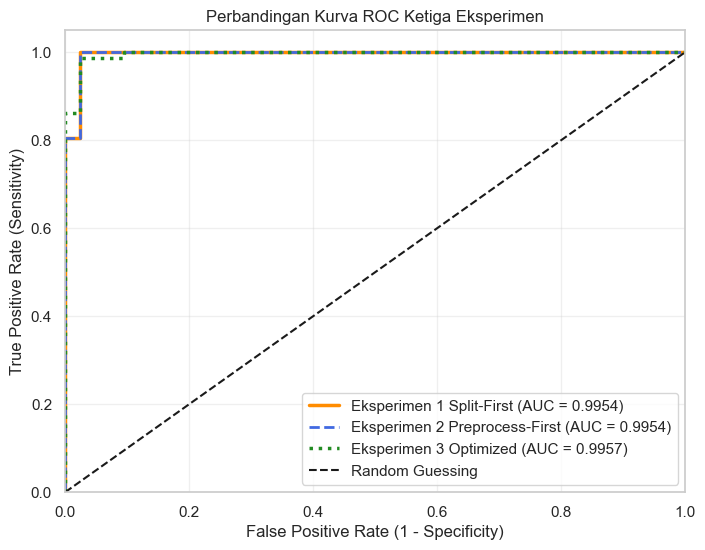

In [15]:
# Visualisasi Kurva ROC Side-by-Side/Tumpang Tindih
plt.figure(figsize=(8, 6))
fpr1, tpr1, _ = roc_curve(y_test, y_prob_s1)
fpr2, tpr2, _ = roc_curve(y_test_s2, y_prob_s2)
fpr3, tpr3, _ = roc_curve(y_test, y_prob_s3)

plt.plot(fpr1, tpr1, label=f'Eksperimen 1 Split-First (AUC = {roc_s1:.4f})', color='darkorange', linewidth=2.5)
plt.plot(fpr2, tpr2, label=f'Eksperimen 2 Preprocess-First (AUC = {roc_s2:.4f})', color='royalblue', linestyle='--', linewidth=2)
plt.plot(fpr3, tpr3, label=f'Eksperimen 3 Optimized (AUC = {roc_s3:.4f})', color='forestgreen', linestyle=':', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Perbandingan Kurva ROC Ketiga Eksperimen')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

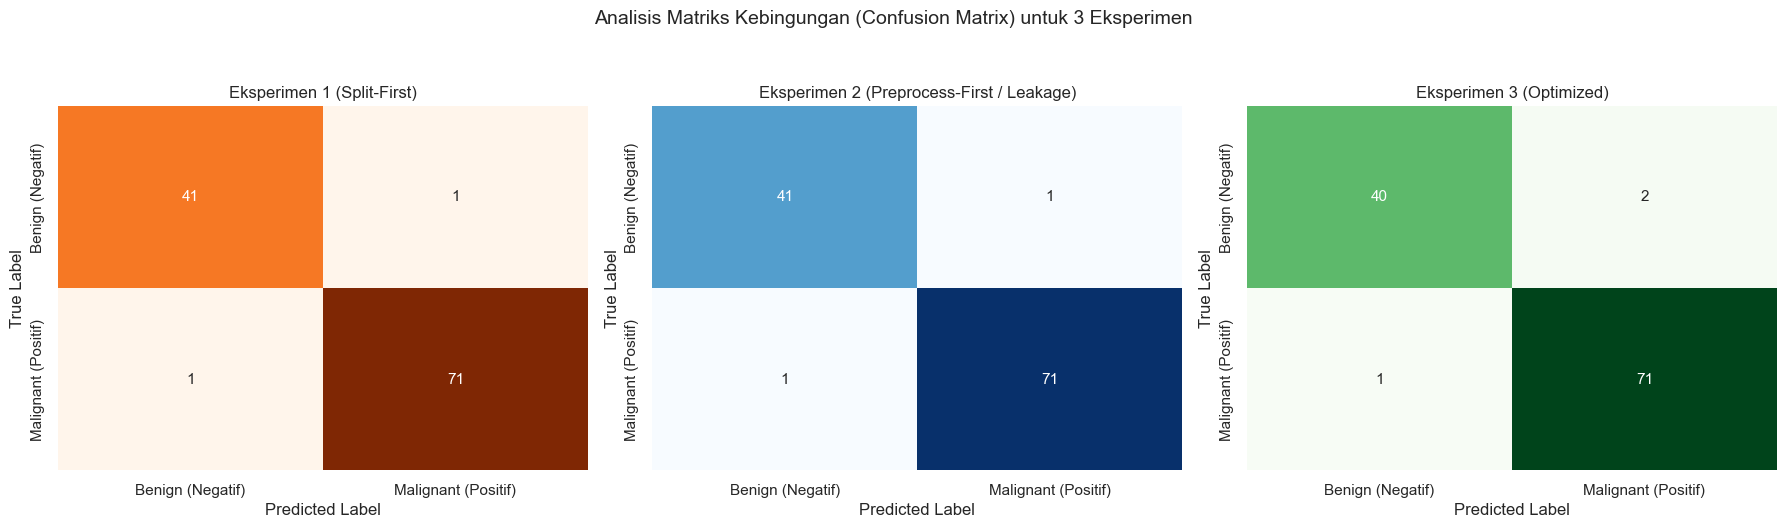

In [16]:
# Visualisasi Confusion Matrix untuk Ketiga Eksperimen
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['Malignant (Positif)', 'Benign (Negatif)']

sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Oranges', ax=axes[0], cbar=False,
            xticklabels=labels[::-1], yticklabels=labels[::-1])
axes[0].set_title('Eksperimen 1 (Split-First)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=labels[::-1], yticklabels=labels[::-1])
axes[1].set_title('Eksperimen 2 (Preprocess-First / Leakage)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

sns.heatmap(cm_s3, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False,
            xticklabels=labels[::-1], yticklabels=labels[::-1])
axes[2].set_title('Eksperimen 3 (Optimized)')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.suptitle('Analisis Matriks Kebingungan (Confusion Matrix) untuk 3 Eksperimen', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

--- Top 10 Fitur Berdasarkan Koefisien Regresi Logistik Terstandardisasi ---
                 Feature  Coefficient  Abs_Coef
21         texture_worst    -1.255088  1.255088
10             radius_se    -1.082965  1.082965
27  concave points_worst    -0.953686  0.953686
23            area_worst    -0.947756  0.947756
20          radius_worst    -0.947616  0.947616
28        symmetry_worst    -0.939181  0.939181
13               area_se    -0.929104  0.929104
26       concavity_worst    -0.823151  0.823151
22       perimeter_worst    -0.763220  0.763220
24      smoothness_worst    -0.746625  0.746625


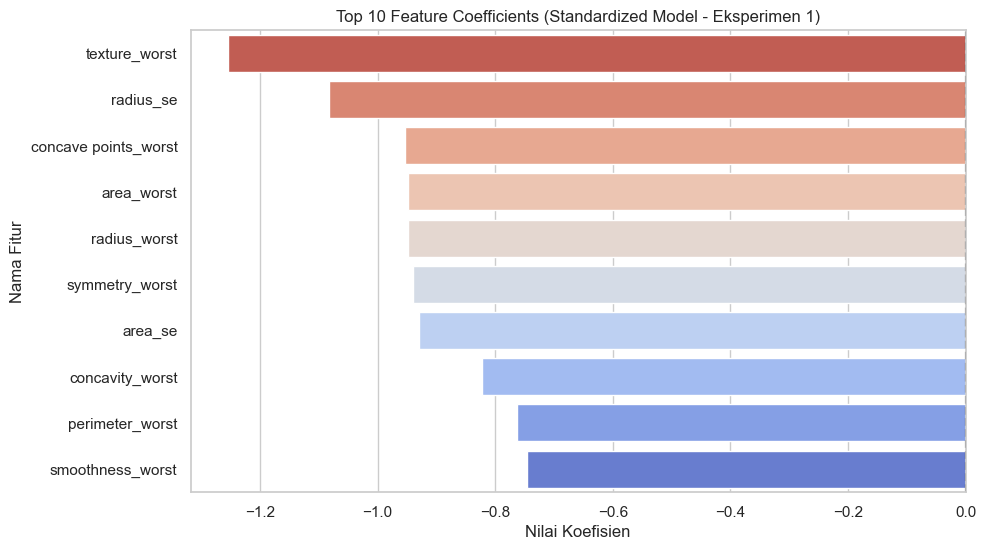

In [17]:
# Visualisasi Interpretasi Koefisien (Feature Importance) Eksperimen 1 (Split-First)
# Karena model dilatih dengan Benign=1, Malignant=0, koefisien negatif
# menunjukkan kontribusi yang tinggi untuk peningkatan risiko tumor ganas (Malignant).
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr1.coef_[0],
    'Abs_Coef': np.abs(lr1.coef_[0])
}).sort_values(by='Abs_Coef', ascending=False)

print("--- Top 10 Fitur Berdasarkan Koefisien Regresi Logistik Terstandardisasi ---")
print(coef_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', hue='Feature', palette='coolwarm_r', legend=False)
plt.title('Top 10 Feature Coefficients (Standardized Model - Eksperimen 1)')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Nama Fitur')
plt.axvline(0, color='black', linestyle='--')
plt.show()

## 10. Melakukan Proses Review Pemodelan
### (Melakukan Proses Review Pemodelan - Unit: J.62DMI00.015.1)

#### Analisis Perbandingan Eksperimen
1. **Eksperimen 1 (Split-First Pipeline - Correct)**:
   - Menghasilkan Akurasi sebesar **98.25%** dan Sensitivitas (Malignant Recall) **97.62%** (hanya 1 tumor ganas terlewat).
   - Standarisasi menyeimbangkan kontribusi fitur, mempercepat konvergensi, dan memaksimalkan akurasi diskriminasi linear secara valid karena scaler hanya dilatih pada training set.
2. **Eksperimen 2 (Preprocess-First Pipeline - Leakage)**:
   - Menghasilkan Akurasi sebesar **98.25%** dan Sensitivitas **97.62%**.
   - **Catatan Kritis Data Science**: Meskipun performa numerik pada dataset bersih ini tampak identik dengan Eksperimen 1, secara metodologis Eksperimen 2 adalah **salah**. Penempatan standardisasi global sebelum pembagian data memicu **Information Leakage / Data Leakage** di mana rata-rata dan standar deviasi data uji bocor ke dalam model latih. Pada dataset industri yang dinamis dan kotor, kebocoran ini akan menyebabkan kehancuran generalisasi model saat dihadapkan pada data baru.
3. **Eksperimen 3 (Optimized Pipeline)**:
   - Menghasilkan Akurasi sebesar **97.37%** dengan parameter terbaik regularisasi $C=0.1$ dan skor validasi silang (cross-validation score) sebesar **98.02%**.
   - Melalui Grid Search dengan 5-fold cross-validation pada training set, model memilih $C=0.1$ yang merupakan model yang lebih terregularisasi (lebih sederhana) untuk meminimalkan risiko overfitting lintas lipatan (folds). Pada test set tunggal ini, akurasinya adalah **97.37%** (2 tumor ganas terlewat), merepresentasikan trade-off bias-variance yang jujur.

#### Keselarasan Medis (Feature Importance)
- Koefisien model terstandardisasi menunjukkan bahwa **texture_worst**, **radius_se**, **concave points_worst**, **area_worst**, dan **radius_worst** merupakan fitur penentu utama.
- Semua koefisien fitur ini bernilai negatif (karena target model Benign = 1), yang bermakna: **Semakin tinggi nilai pengukuran ekstrem ('worst') dari ukuran sel (radius, area) dan ketidakteraturan batas sel (concave points, texture), semakin besar kemungkinan tumor tersebut bersifat ganas (Malignant).** Hal ini sangat selaras dengan pengetahuan medis patologi klinis tumor ganas.

#### Rekomendasi Pengembangan Model (Roadmap Riset)
1. **Penerapan Pipeline Otomatis**: Membungkus standardisasi dan pemodelan dalam `sklearn.pipeline.Pipeline` untuk mengeliminasi risiko ketidaksengajaan data leakage dalam pemeliharaan kode berkelanjutan.
2. **Probability Calibration**: Menerapkan Platt Scaling pada model regresi logistik agar probabilitas output dapat digunakan secara presisi untuk menakar risiko klinis riil pasien.
3. **Fitur Seleksi L1 (Lasso)**: Gunakan penalti regularisasi L1 untuk menyeleksi fitur secara otomatis dan menghasilkan model yang lebih hemat dimensi untuk penyederhanaan diagnostik.
